In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI
import h5py
import pandas as pd


In [4]:
exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata\02\004\34224_03CB_02_004_009_01_Decay1.h5m"


lookback_window = 5.0      # seconden vóór decay-start waarin we de amplitude zoeken
quiet_window_end = 12.0     # rustige periode eindigt 12 s vóór decay-start
quiet_window_length = 50.0


In [7]:
with h5py.File(exp_path, "r") as f:
    t_exp = f["CroppedSignals/time"][:]
    z_exp = f["CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)"][:]
    t_unfiltered = f["UnfilteredSignals/time"][:]
    z_unfiltered = f["UnfilteredSignals/Z_COG (unfiltered)"][:]

# DataFrames in één keer maken
df_exp = pd.DataFrame({
    "time [s]": t_exp,
    "time_norm [s]": t_exp - t_exp[0],
    "z_exp [m]": z_exp
})

df_unfiltered = pd.DataFrame({
    "time [s]": t_unf,
    "z_unfiltered [m]": z_unf
})

In [8]:
t_decay_start = t_exp[0]

# -----------------------------
# 2. rustige periode in ongefilterd signaal kiezen
#    van (start - quiet_window_end - quiet_window_length) tot (start - quiet_window_end)
# -----------------------------
quiet_start = t_decay_start - quiet_window_end - quiet_window_length
quiet_end = t_decay_start - quiet_window_end

mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

if not np.any(mask_quiet):
    raise ValueError("Geen data gevonden in de gekozen rustige periode. Kies andere vensters.")

z_eq = np.mean(z_unfiltered[mask_quiet])

# -----------------------------
# 3. zoekvenster voor initiële amplitude
#    10 s vóór decay-start
# -----------------------------
search_start = t_decay_start - lookback_window
search_end = t_decay_start

mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

if not np.any(mask_search):
    raise ValueError("Geen data gevonden in het zoekvenster vóór de decay-start.")

t_search = t_unfiltered[mask_search]
z_search = z_unfiltered[mask_search]

# afwijking t.o.v. evenwicht
deviation = z_search - z_eq

# index van grootste absolute uitslag
idx_local = np.argmax(np.abs(deviation))

t_init = t_search[idx_local]
z_init = z_search[idx_local]
A0 = np.abs(z_init - z_eq)

print(f"Decay start time           = {t_decay_start:.3f} s")
print(f"Quiet window               = [{quiet_start:.3f}, {quiet_end:.3f}] s")
print(f"Equilibrium level z_eq     = {z_eq:.6f} m")
print(f"Search window              = [{search_start:.3f}, {search_end:.3f}] s")
print(f"Initial extreme at t       = {t_init:.3f} s")
print(f"Initial extreme z          = {z_init:.6f} m")
print(f"Initial amplitude A0       = {A0:.6f} m")
print(f"Signed amplitude           = {z_init - z_eq:.6f} m")

Decay start time           = 226.890 s
Quiet window               = [164.890, 214.890] s
Equilibrium level z_eq     = 0.006128 m
Search window              = [221.890, 226.890] s
Initial extreme at t       = 222.184 s
Initial extreme z          = -1.039802 m
Initial amplitude A0       = 1.045930 m
Signed amplitude           = -1.045930 m


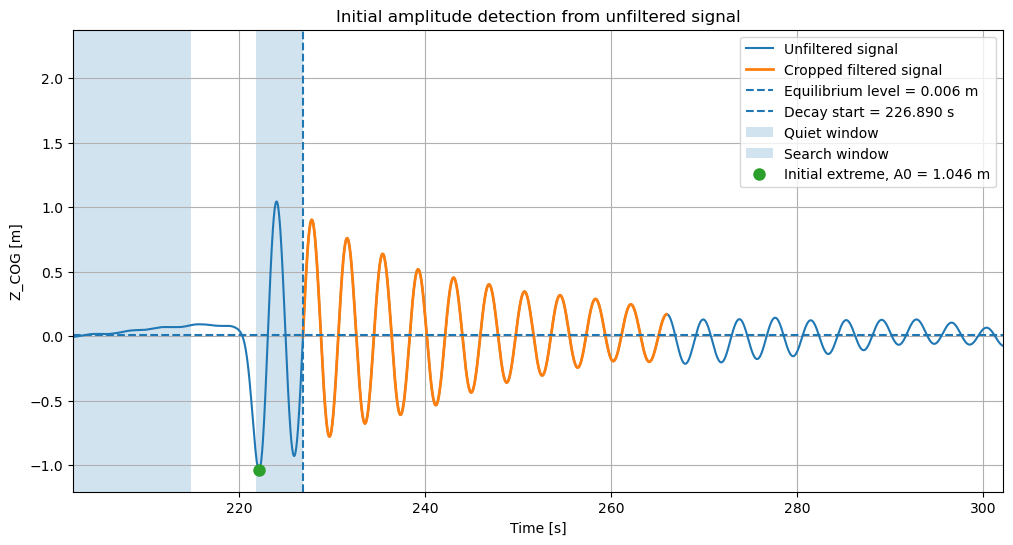

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(t_unfiltered, z_unfiltered, label="Unfiltered signal")
plt.plot(t_exp, z_exp, label="Cropped filtered signal", linewidth=2)

# evenwichtsniveau
plt.axhline(z_eq, linestyle="--", label=f"Equilibrium level = {z_eq:.3f} m")

# decay-start
plt.axvline(t_decay_start, linestyle="--", label=f"Decay start = {t_decay_start:.3f} s")

# rustige periode
plt.axvspan(quiet_start, quiet_end, alpha=0.2, label="Quiet window")

# zoekvenster
plt.axvspan(search_start, search_end, alpha=0.2, label="Search window")

# gevonden initiële amplitude
plt.plot(t_init, z_init, "o", markersize=8, label=f"Initial extreme, A0 = {A0:.3f} m")
plt.xlim(t_init - 20, t_init + 80)
plt.xlabel("Time [s]")
plt.ylabel("Z_COG [m]")
plt.title("Initial amplitude detection from unfiltered signal")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# plt.figure(figsize=(10, 5))
# plt.plot(df_exp["time [s]"], df_exp["z_exp [m]"])

# plt.xlabel("Time [s]")
# plt.ylabel("Z_COG [m]")
# plt.title("Experimental decay (time normalized)")
# plt.grid(True)
# plt.show()

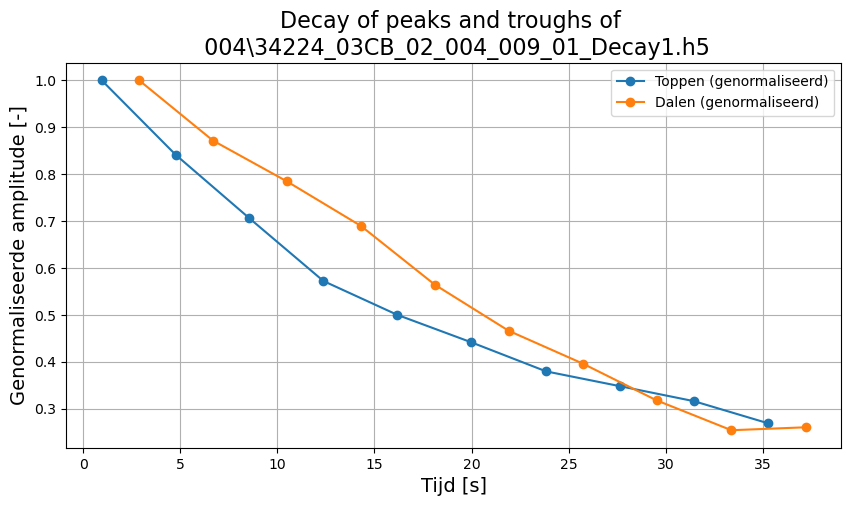

In [10]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt


TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12

# -----------------------------
# 1. werk met decay signaal (gefilterd)
# -----------------------------
t_decay = t_exp - t_decay_start
z_decay = z_exp - z_eq

# -----------------------------
# 2. pieken en dalen vinden
# -----------------------------
prom = 0.001  # eventueel aanpassen!

peaks, _ = find_peaks(z_decay, prominence=prom)
troughs, _ = find_peaks(-z_decay, prominence=prom)

t_peaks = t_decay[peaks]
z_peaks = z_decay[peaks]

t_troughs = t_decay[troughs]
z_troughs = z_decay[troughs]

# -----------------------------
# 3. amplitude (absolute waarde)
# -----------------------------
A_peaks = z_peaks
A_troughs = -z_troughs  # negatief → positief maken

# -----------------------------
# 4. normaliseren op eerste waarde (optioneel)
# -----------------------------
A_peaks_norm = A_peaks / A_peaks[0]
A_troughs_norm = A_troughs / A_troughs[0]

# -----------------------------
# 5. plot amplitude decay
# -----------------------------
plt.figure(figsize=(10, 5))

plt.plot(t_peaks, A_peaks_norm, 'o-', label="Toppen (genormaliseerd)")
plt.plot(t_troughs, A_troughs_norm, 'o-', label="Dalen (genormaliseerd)")

plt.xlabel("Tijd [s]", fontsize = LABEL_SIZE)
plt.ylabel("Genormaliseerde amplitude [-]", fontsize = LABEL_SIZE)
plt.title(f"Decay of peaks and troughs of \n {exp_path[-39:-1]}", fontsize = TITLE_SIZE)
plt.grid(True)
plt.legend()

plt.show()